# 03 — Biological interpretation

Uses **`results/top_cpgs.csv`** from notebook 02 (non-zero Elastic Net coefficients), merges Illumina 450k manifest annotations, compares against Horvath clock probes, runs a Fisher exact test on overlap versus the full array background (size from **`data/processed/n_cpgs.txt`**), performs GOterm enrichment via **g:Profiler**, and saves consolidated tables.

**Prerequisites:** run `01_data_loading.ipynb` (creates `n_cpgs.txt`) and `02_model_training.ipynb` (creates `top_cpgs.csv`).

## Dependencies

In [1]:
%pip install -q pandas scipy matplotlib

Note: you may need to restart the kernel to use updated packages.


## Paths

In [2]:
from pathlib import Path

PROJECT_DIR = Path("..").resolve()
RAW_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
RESULTS_DIR = PROJECT_DIR / "results"

RAW_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

## Load model probes and array background size

`n_cpgs.txt` avoids reloading the full beta matrix for the Fisher exact background.

In [3]:
import pandas as pd

top_path = RESULTS_DIR / "top_cpgs.csv"
n_cpgs_path = PROCESSED_DIR / "n_cpgs.txt"

if not top_path.is_file():
    raise FileNotFoundError(
        "Run 02_model_training.ipynb first. Missing:\n" + str(top_path)
    )
if not n_cpgs_path.is_file():
    raise FileNotFoundError(
        "Run 01_data_loading.ipynb first. Missing:\n" + str(n_cpgs_path)
    )

top_cpgs_df = pd.read_csv(top_path)
n_cpgs_background = int(n_cpgs_path.read_text(encoding="utf-8").strip())

top_cpgs_df = top_cpgs_df.rename(columns={"ID_REF": "cpg"})
my_cpgs = set(top_cpgs_df["cpg"].astype(str))

print("Non-zero model probes:", len(my_cpgs))
print("Array background CpGs:", n_cpgs_background)

Non-zero model probes: 691
Array background CpGs: 473034


## Illumina 450k manifest (download once, cache locally)

In [4]:
annotation_url = (
    "https://webdata.illumina.com/downloads/productfiles/"
    "humanmethylation450/humanmethylation450_15017482_v1-2.csv"
)
annotation_path = RAW_DIR / "illumina450k_annotation.csv"

if not annotation_path.exists():
    annotation = pd.read_csv(annotation_url, skiprows=7, low_memory=False)
    annotation.to_csv(annotation_path, index=False)
else:
    annotation = pd.read_csv(annotation_path, low_memory=False)

print("Manifest shape:", annotation.shape)

Manifest shape: (486428, 33)


## Merge annotations → `top_cpgs_annotated.csv`

In [5]:
annotation_subset = annotation[[
    "IlmnID", "CHR", "MAPINFO",
    "UCSC_RefGene_Name", "UCSC_RefGene_Group",
    "Relation_to_UCSC_CpG_Island",
]].copy()

merged = top_cpgs_df.merge(
    annotation_subset,
    left_on="cpg",
    right_on="IlmnID",
    how="left",
)

annotated_path = RESULTS_DIR / "top_cpgs_annotated.csv"
merged.to_csv(annotated_path, index=False)
display(merged.head(15))

,cpg,coefficient,abs_coef,IlmnID,CHR,MAPINFO,UCSC_RefGene_Name,UCSC_RefGene_Group,Relation_to_UCSC_CpG_Island
0,cg16867657,0.770339,0.770339,cg16867657,6,11044877.0,ELOVL2,TSS1500,Island
1,cg22637865,0.714293,0.714293,cg22637865,22,43486524.0,TTLL1;TTLL1,TSS1500;TSS1500,S_Shore
2,cg02867102,-0.697163,0.697163,cg02867102,17,62398693.0,NaN,NaN,NaN
3,cg07181952,0.589662,0.589662,cg07181952,1,1239999.0,ACAP3,Body,N_Shelf
4,cg21874213,-0.589462,0.589462,cg21874213,5,139229292.0,NRG2;NRG2;NRG2;NRG2,Body;Body;Body;Body,S_Shore
5,cg18468844,0.541216,0.541216,cg18468844,1,28503720.0,PTAFR;PTAFR;PTAFR;PTAFR,TSS1500;TSS1500;5'UTR;5'UTR,NaN
6,cg27599792,-0.508143,0.508143,cg27599792,5,140792992.0,PCDHGA4;PCDHGA6;PCDHGA9;PCDHGA1;PCDHGA8;PCDHGA...,Body;Body;Body;Body;Body;Body;Body;1stExon;Bod...,N_Shore
7,cg08993878,-0.508129,0.508129,cg08993878,12,98151379.0,NaN,NaN,NaN
8,cg18647570,0.506191,0.506191,cg18647570,17,41594616.0,DHX8,Body,NaN
9,cg06419432,-0.477841,0.477841,cg06419432,17,25707535.0,NaN,NaN,NaN


## Horvath clock probes (supplementary CSV)

Place **`13059_2013_3156_MOESM3_ESM.csv`** under `data/raw/` (Horvath et al., Genome Biology 2013 supplementary).

In [6]:
horvath_csv = RAW_DIR / "13059_2013_3156_MOESM3_ESM.csv"
if not horvath_csv.is_file():
    raise FileNotFoundError(
        "Expected Horvath supplementary CSV at:\n" + str(horvath_csv)
    )

horvath_raw = pd.read_csv(horvath_csv, header=None)
new_columns = horvath_raw.iloc[2].tolist()
horvath = horvath_raw.iloc[3:].copy()
horvath.columns = new_columns
horvath = horvath.reset_index(drop=True)
horvath = horvath[horvath["CpGmarker"] != "(Intercept)"].copy()
horvath_cpgs = set(horvath["CpGmarker"].astype(str))
print("Horvath probes:", len(horvath_cpgs))

Horvath probes: 353


## Overlap table → `horvath_overlap.csv`

In [7]:
overlap = my_cpgs & horvath_cpgs
print("Overlap size:", len(overlap))

overlap_df = merged[merged["cpg"].isin(overlap)].copy()
overlap_df = overlap_df.merge(
    horvath[[
        "CpGmarker", "CoefficientTraining", "CoefficientTrainingShrunk",
        "Symbol", "Marginal Age Relationship",
    ]],
    left_on="cpg",
    right_on="CpGmarker",
    how="left",
)
overlap_df = overlap_df.sort_values("abs_coef", ascending=False)

horvath_overlap_path = RESULTS_DIR / "horvath_overlap.csv"
overlap_df.to_csv(horvath_overlap_path, index=False)

display(
    overlap_df[[
        "cpg", "coefficient", "abs_coef", "UCSC_RefGene_Name", "Symbol",
        "CoefficientTraining", "CoefficientTrainingShrunk",
        "Marginal Age Relationship",
    ]].head(20)
)

Overlap size: 9


,cpg,coefficient,abs_coef,UCSC_RefGene_Name,Symbol,CoefficientTraining,CoefficientTrainingShrunk,Marginal Age Relationship
0,cg04474832,-0.312227,0.312227,ABHD14B;ABHD14B;ABHD14B;ABHD14A;ABHD14B;ABHD14B,ABHD14A,-0.444042106,-0.275148589,negative
1,cg07158339,-0.181546,0.181546,FXN;FXN;FXN,FXN,-0.626329239,-0.490713553,negative
2,cg19945840,0.170330,0.170330,SDF4;SDF4;B3GALT6,B3GALT6,0.62850032,0.763203816,positive
3,cg06493994,0.169243,0.169243,SCGN;SCGN,SCGN,1.858006164,1.677018893,positive
4,cg10865119,0.169144,0.169144,C6orf122;C6orf208,C6orf208,-0.069157921,NaN,negative
5,cg09809672,-0.119019,0.119019,EDARADD;EDARADD;EDARADD,EDARADD,-0.391318905,-0.189294522,negative
6,cg17589341,0.110748,0.110748,SLC14A1;SLC14A1;SLC14A1,SLC14A1,-0.065957735,NaN,negative
7,cg02479575,0.028599,0.028599,MIR7-3;C19orf30,C19orf30,1.875446187,2.039720589,positive
8,cg26614073,-0.002636,0.002636,SCAP,SCAP,-0.506521375,-0.740945549,negative


## Fisher exact test (overlap enrichment vs array background)

In [8]:
from scipy.stats import fisher_exact

a = len(overlap)
b = len(my_cpgs - horvath_cpgs)
c = len(horvath_cpgs - my_cpgs)
d = n_cpgs_background - len(my_cpgs | horvath_cpgs)

table = [[a, b], [c, d]]
odds_ratio, p_value = fisher_exact(table, alternative="greater")

print("Contingency table [[overlap, model_only],[horvath_only, neither]]:")
print(table)
print("Odds ratio:", odds_ratio)
print("One-sided P (greater overlap):", p_value)

Contingency table [[overlap, model_only],[horvath_only, neither]]:
[[9, 682], [344, 471999]]
Odds ratio: 18.106761065266316
One-sided P (greater overlap): 3.8953117800418156e-09


## GO term enrichment (g:Profiler REST)

Gene symbols are parsed from **`UCSC_RefGene_Name`** (same convention as the training notebook).

In [9]:
import json
import urllib.request


def refgene_to_symbols(refgene):
    if pd.isna(refgene) or refgene == "":
        return []
    symbols = []
    for chunk in str(refgene).split(";"):
        chunk = chunk.strip()
        if not chunk:
            continue
        base = chunk.split("(")[0].strip()
        if base:
            symbols.append(base)
    return symbols


genes = []
for val in merged["UCSC_RefGene_Name"]:
    genes.extend(refgene_to_symbols(val))

query_genes = sorted(set(genes))
print("Unique gene symbols for enrichment:", len(query_genes))


def run_gprofiler(query, organism="hsapiens"):
    url = "https://biit.cs.ut.ee/gprofiler/api/gost/profile/"
    payload = {
        "query": query,
        "organism": organism,
        "sources": ["GO:BP", "GO:MF", "GO:CC"],
        "user_threshold": 0.05,
        "significance_threshold_method": "g_SCS",
        "all_results": False,
    }
    data = json.dumps(payload).encode("utf-8")
    req = urllib.request.Request(
        url,
        data=data,
        headers={"Content-Type": "application/json"},
        method="POST",
    )
    with urllib.request.urlopen(req, timeout=180) as resp:
        return json.loads(resp.read().decode("utf-8"))


go_rows = []
if query_genes:
    gprof = run_gprofiler(query_genes)
    for item in gprof.get("result", []) or []:
        go_rows.append(
            {
                "analysis_type": "gprofiler_go",
                "native_id": item.get("native"),
                "term_name": item.get("name"),
                "source": item.get("source"),
                "p_value": item.get("p_value"),
                "term_size": item.get("term_size"),
                "query_size": item.get("query_size"),
                "intersection_size": item.get("intersection_size"),
                "recall": item.get("recall"),
                "precision": item.get("precision"),
            }
        )
else:
    print("No genes parsed from annotation; skipping g:Profiler.")

go_df = pd.DataFrame(go_rows)
if not go_df.empty:
    go_df = go_df.sort_values(["source", "p_value", "native_id"])
display(go_df.head(20))

Unique gene symbols for enrichment: 562


,analysis_type,native_id,term_name,source,p_value,term_size,query_size,intersection_size,recall,precision
0,gprofiler_go,GO:0007156,homophilic cell-cell adhesion,GO:BP,1.604188e-21,169,439,35,0.207101,0.079727
1,gprofiler_go,GO:0048731,system development,GO:BP,5.034095e-14,4023,439,159,0.039523,0.362187
2,gprofiler_go,GO:0007275,multicellular organism development,GO:BP,1.520091e-13,4690,439,175,0.037313,0.398633
3,gprofiler_go,GO:0032501,multicellular organismal process,GO:BP,1.740196e-12,7337,439,235,0.032029,0.535308
6,gprofiler_go,GO:0048856,anatomical structure development,GO:BP,1.733899e-11,5948,439,200,0.033625,0.455581
7,gprofiler_go,GO:0007399,nervous system development,GO:BP,2.457439e-11,2597,439,113,0.043512,0.257403
8,gprofiler_go,GO:0007155,cell adhesion,GO:BP,5.590340e-10,1512,439,77,0.050926,0.175399
9,gprofiler_go,GO:0098609,cell-cell adhesion,GO:BP,1.014634e-09,965,439,58,0.060104,0.132118
10,gprofiler_go,GO:0032502,developmental process,GO:BP,1.214823e-09,6535,439,208,0.031829,0.473804
18,gprofiler_go,GO:0010646,regulation of cell communication,GO:BP,1.340272e-03,3480,439,113,0.032471,0.257403


## Combine Fisher summary + GO results → `enrichment_results.csv`

In [10]:
fisher_df = pd.DataFrame(
    [
        {
            "analysis_type": "fisher_exact_horvath_overlap",
            "native_id": "FISHER",
            "term_name": "CpG overlap vs expected (model ∩ Horvath)",
            "source": "overlap_test",
            "p_value": float(p_value),
            "odds_ratio": float(odds_ratio),
            "a_overlap": int(a),
            "b_model_only": int(b),
            "c_horvath_only": int(c),
            "d_neither": int(d),
            "n_my_cpgs": len(my_cpgs),
            "n_horvath_cpgs": len(horvath_cpgs),
            "n_background_cpgs": int(n_cpgs_background),
        }
    ]
)

if go_df.empty:
    enrichment_all = fisher_df.copy()
else:
    enrichment_all = pd.concat([fisher_df, go_df], ignore_index=True, sort=False)

enrichment_path = RESULTS_DIR / "enrichment_results.csv"
enrichment_all.to_csv(enrichment_path, index=False)

## Biological plots

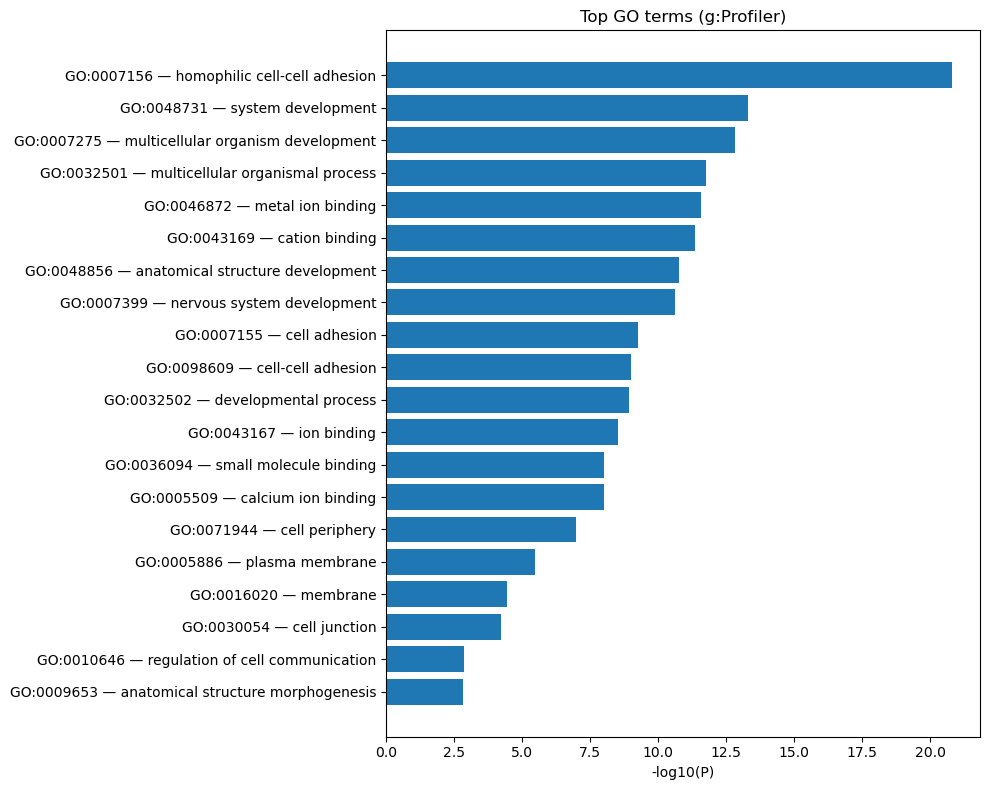

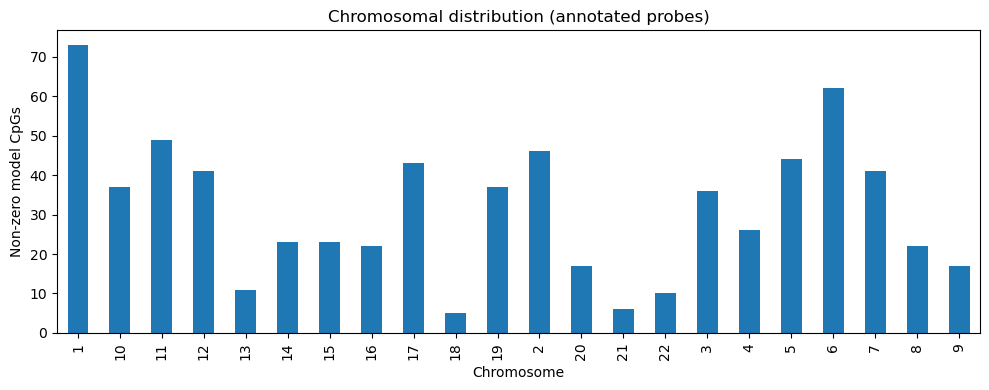

In [11]:
import matplotlib.pyplot as plt
import numpy as np

if not go_df.empty:
    plot_df = go_df.dropna(subset=["p_value"]).copy()
    plot_df = plot_df.nsmallest(20, "p_value")
    plot_df["neglog10_p"] = -np.log10(plot_df["p_value"].clip(lower=1e-300))

    fig, ax = plt.subplots(figsize=(10, 8))
    order = plot_df.sort_values("neglog10_p")
    labels = [
        f"{row['native_id']} — {str(row['term_name'])[:60]}"
        for _, row in order.iterrows()
    ]
    ax.barh(labels, order["neglog10_p"])
    ax.set_xlabel("-log10(P)")
    ax.set_title("Top GO terms (g:Profiler)")
    fig.tight_layout()
    plt.show()

chr_counts = merged["CHR"].astype(str).value_counts().sort_index()
fig2, ax2 = plt.subplots(figsize=(10, 4))
chr_counts.plot(kind="bar", ax=ax2)
ax2.set_xlabel("Chromosome")
ax2.set_ylabel("Non-zero model CpGs")
ax2.set_title("Chromosomal distribution (annotated probes)")
fig2.tight_layout()
plt.show()

## Export summary

In [12]:
exports = [
    annotated_path,
    horvath_overlap_path,
    enrichment_path,
]
print("Exported:")
for p in exports:
    print(" -", p.resolve())

Exported:
 - C:\Users\Eva\Desktop\Longevity\Projects\epigenetic-clock-reproduction\results\top_cpgs_annotated.csv
 - C:\Users\Eva\Desktop\Longevity\Projects\epigenetic-clock-reproduction\results\horvath_overlap.csv
 - C:\Users\Eva\Desktop\Longevity\Projects\epigenetic-clock-reproduction\results\enrichment_results.csv
